# CellTypist - Bacteria dataset 
This CellTypist tutorial is applied on a Bacterie scRNA-seq dataset that consists of 2 celltypes: BF (biofilm cells) and P (Plaktonic)
We build an unsupervised learning model by applying PCA → neighbors → UMAP → Leiden clustering (unsupervised) → daarna CellTypist annotatie

## 1. Install CellTypist Package

In [1]:
# CellTypist - Bacteria dataset (gecorrigeerde versie)
# Dataset: Staphylococcus aureus, 2 celltypes: BF (Biofilm) en P (Planktonic)
# Pipeline: PCA → neighbors → UMAP → Leiden clustering → CellTypist annotatie
#!pip install celltypist


## 2. Import the libraries

In [2]:
import scanpy as sc          # toolkit for single-cell analysis
import celltypist            # automatic cell-annotation
from celltypist import models  # to download specific models
import numpy as np           # calculations
import matplotlib.pyplot as plt  # making graphs
 
sc.settings.verbosity = 1    # Only show errors and warnings
sc.settings.set_figure_params(dpi=100, frameon=False)  # Set figure quality

/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarn

## 3. Data loading and preprocessing
This dataset contains Staphylococcus aureus bacteria in two distinct growth states: Biofilm (BF) and Planktonic (P). The aim of this study is to compare how these two populations differ in gene expression at the single-cell level. Biofilm cells are significantly harder to treat, as they are encased in a protective extracellular matrix that makes them highly resistant to antibiotics and the host immune system. Understanding the transcriptional differences between biofilm and planktonic cells is therefore critical for identifying potential therapeutic targets.

In [3]:
# Step 1: Load the raw files separately
#adata_bf = sc.read_h5ad("../data/BF_count_mat.h5ad") #to open the raw counts, and drop them in an object callaed adata_bf

# Step 2: Ribo-filter for BOTH datasets
#adata_bf.var_names_make_unique()
#adata_bf.var["ribo"] = adata_bf.var_names.str.lower().str.startswith(("rps","rpl","rpm","rrs","rrl","rrf"))
#adata_bf = adata_bf[:, ~adata_bf.var["ribo"]].copy() #look for genes, ribosomal genes > we remove these to minimilize the trash (=ruis)

# Step 3: Count-filter on raw data (cutoffs from paper)
#adata_bf.obs['counts'] = adata_bf.X.sum(axis=1) #shows how many signals are detected per cell
#adata_bf = adata_bf[adata_bf.obs['counts'] >= 7].copy() #if the cell has less than 7 measure signals, then it will be removed 

# Step 4: Normalization 
#sc.pp.normalize_total(adata_bf, target_sum=1e4) #every cell has exactly 10000 counts 
#sc.pp.log1p(adata_bf)
# Stap 5: Sla de gefilterde data op (DIT MOET ER NOG BIJ!)
#adata_bf.write("../data/BF_gefilterd.h5ad", compression="gzip")

In [4]:
# This load the biofilm data 'virtual' in and uses almost no RAM
adata_bf = sc.read_h5ad("../data/BF_gefilterd.h5ad", backed="r")

In [5]:
# Laad ALLES in RAM in één keer (geen backed)
#adata_p = sc.read_h5ad("../data/P_count_mat.h5ad")

# Filter ribo
#adata_p.var_names_make_unique()
#adata_p.var["ribo"] = adata_p.var_names.str.lower().str.startswith(("rps","rpl","rpm","rrs","rrl","rrf"))
#adata_p = adata_p[:, ~adata_p.var["ribo"]].copy()

# Filter cellen
#adata_p.obs["counts"] = adata_p.X.sum(axis=1)
#adata_p = adata_p[adata_p.obs["counts"] >= 28].copy()

# Normaliseer
#sc.pp.normalize_total(adata_p, target_sum=1e4)
#sc.pp.log1p(adata_p)

# Sla op
#adata_p.write("../data/P_gefilterd.h5ad", compression="gzip")


In [6]:
# This load the planktonic data 'virtual' in and uses almost no RAM
adata_p = sc.read_h5ad("../data/P_gefilterd.h5ad", backed="r")

Instead of keeping the entire raw dataset and all intermediate preprocessing steps active in the system's volatile memory (RAM), we execute the heavy preprocessing pipeline **strictly once**. The resulting lightweight, filtered dataset is permanently cached on the local disk as an optimized `.h5ad` file. Subsequent analysis sessions bypass the raw preprocessing completely, minimizing memory usage.

In [7]:
# Step 5: Merge
import anndata as ad
adata_bacteria = ad.concat({"bf": adata_bf, "p": adata_p}, label="sample", join="inner")
adata_bacteria.obs_names_make_unique()

#look at the shape of the dataset,
print("Shape of the dataset:" ,adata_bacteria.shape)

Shape of the dataset: (7437, 2799)


In [8]:
actual_labels = adata_bacteria.obs['sample'].unique()
print(f"Your file actually contains these labels: {actual_labels}")
adata_bacteria.obs.head()

Your file actually contains these labels: ['bf', 'p']
Categories (2, object): ['bf', 'p']


,counts,sample
68,14.120000,bf
96,8.600000,bf
104,16.809999,bf
107,8.700001,bf
131,9.559999,bf


## 4. Dimensionality Reduction and clustering
This section covers the full preprocessing pipeline: HVG selection, scaling, PCA, BBKNN batch correction, UMAP embedding, and Leiden clustering. BBKNN replaces the standard sc.pp.neighbors() call and ensures that each cell finds neighbors both within and across batches, correcting for condition-specific technical variation.

In [9]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import celltypist

# --- 1. HVG selection ---
sc.pp.highly_variable_genes(adata_bacteria, min_mean=0.00625, min_disp=0.25, batch_key='sample')

# --- CRITICAL FIX: save raw BEFORE HVG filtering ---
adata_bacteria.raw = adata_bacteria

# --- 2. Filter to HVGs ---
adata_bacteria = adata_bacteria[:, adata_bacteria.var.highly_variable].copy()

# --- 3. Scale & PCA ---
sc.pp.scale(adata_bacteria, max_value=10)
sc.tl.pca(adata_bacteria, n_comps=10)

# --- 4. BBKNN batch correction ---
sc.external.pp.bbknn(
    adata_bacteria,
    batch_key='sample',
    neighbors_within_batch=9,
    n_pcs=4
)



/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 5. Clustering and visualisation

Number of clusters found: 5


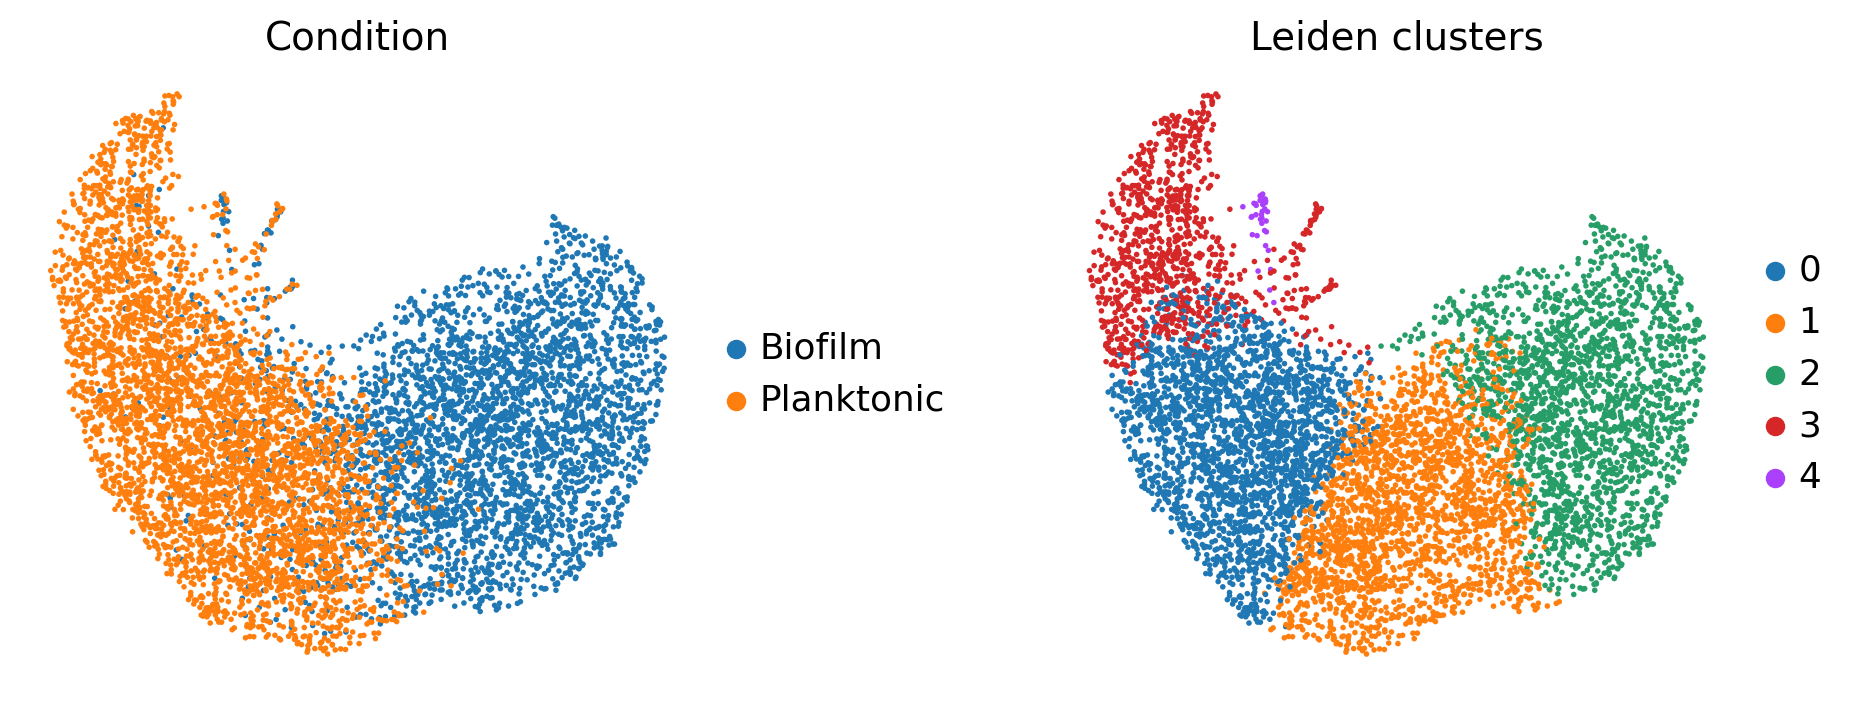

In [10]:
# --- UMAP & Leiden ---
# resolution=0.205 from paper gives ~7 clusters
sc.tl.umap(adata_bacteria, min_dist=0.24, spread=0.21)
sc.tl.leiden(adata_bacteria, resolution=0.205)

# Check how many clusters you got
n_clusters = adata_bacteria.obs['leiden'].nunique()
print(f"Number of clusters found: {n_clusters}")
# Should print 7 - if not, adjust resolution slightly up/down

# --- Labels & visualisation ---
actual_labels = adata_bacteria.obs['sample'].unique()
label_map = {actual_labels[0]: 'Biofilm', actual_labels[1]: 'Planktonic'}
adata_bacteria.obs['Cell identity'] = adata_bacteria.obs['sample'].map(label_map)

sc.pl.umap(
    adata_bacteria,
    color=['Cell identity', 'leiden'],
    title=['Condition', 'Leiden clusters'],
    wspace=0.4,
    frameon=False
)

## 6. Cluster composition (Figure 2D)
We quantify the proportion of Biofilm and Planktonic cells within each Leiden cluster. A normalized stacked bar chart allows direct comparison with Figure 2D from Korshoj & Kielian (2024). Clusters dominated by one condition suggest biologically meaningful separation

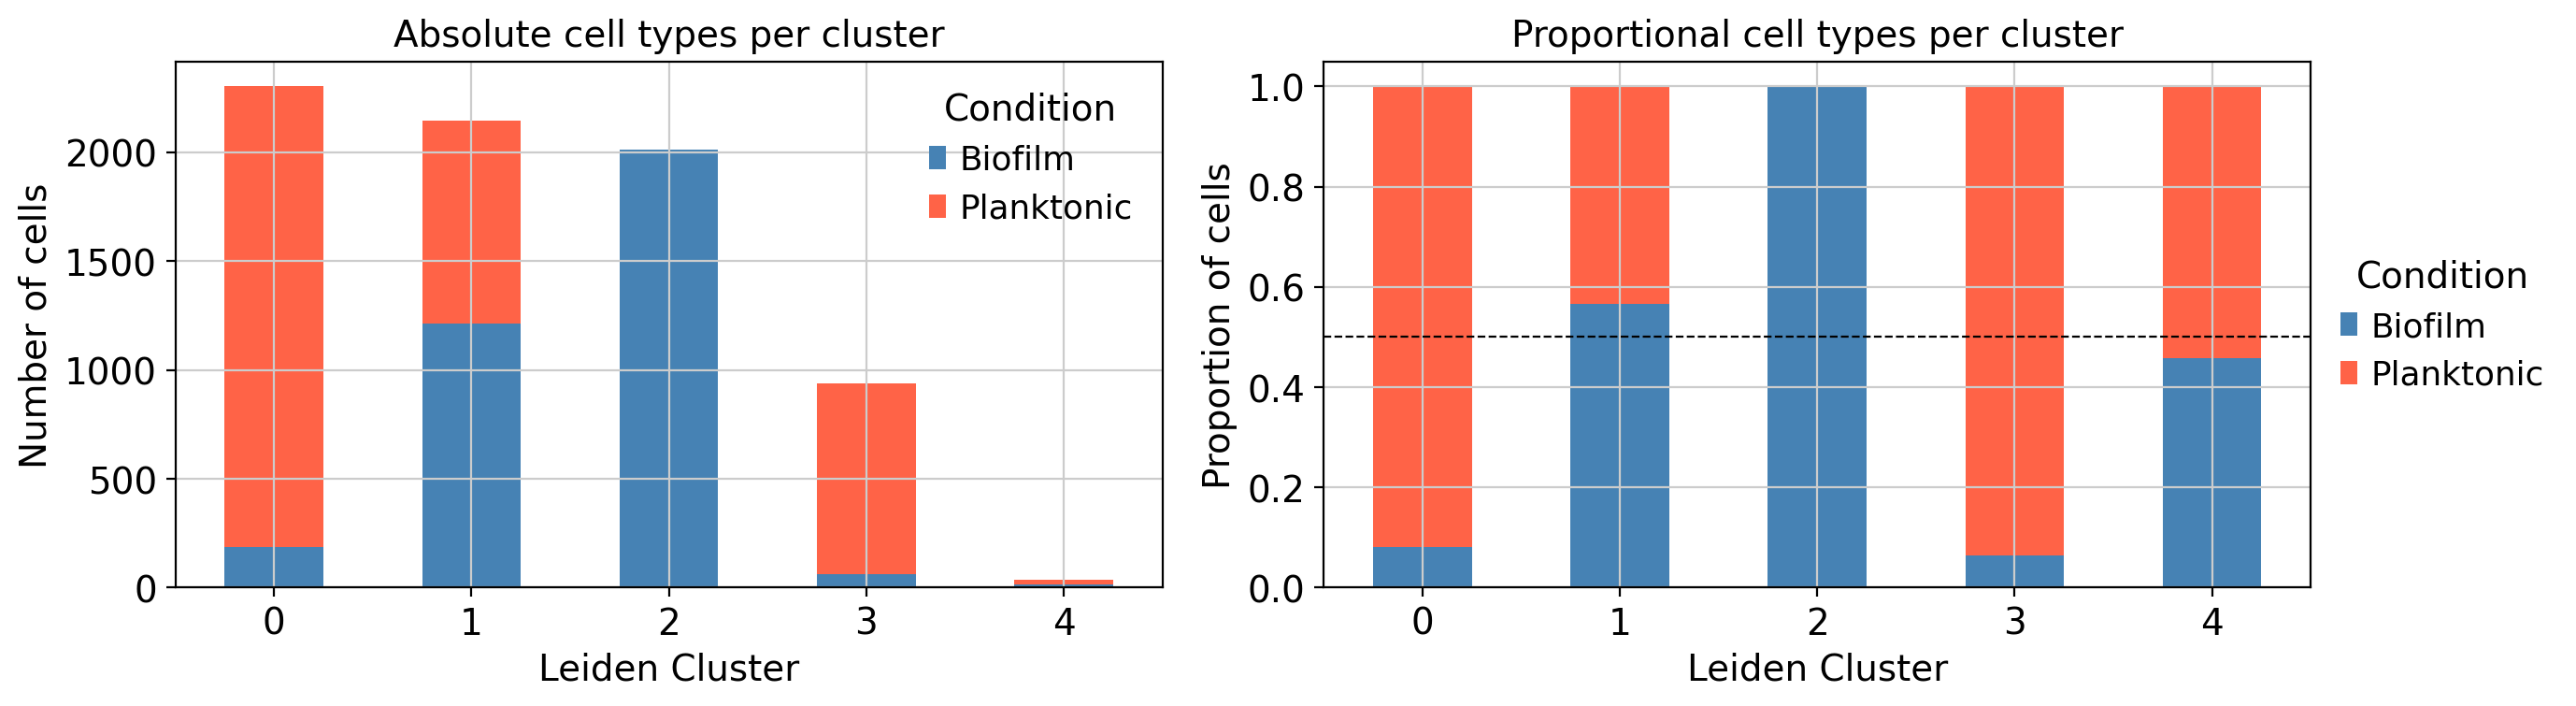

In [11]:
# Use 'Cell identity' column
dist = pd.crosstab(adata_bacteria.obs['leiden'], adata_bacteria.obs['Cell identity'])
dist_norm = dist.div(dist.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
color_map = {'Biofilm': 'steelblue', 'Planktonic': 'tomato'}

# Left: Absolute counts
dist.plot(kind='bar', ax=axes[0], color=color_map, stacked=True)
axes[0].set_ylabel('Number of cells')
axes[0].set_xlabel('Leiden Cluster')
axes[0].set_title('Absolute cell types per cluster')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Condition', frameon=False)

# Right: Normalized proportions
dist_norm.plot(kind='bar', ax=axes[1], color=color_map, stacked=True)
axes[1].set_ylabel('Proportion of cells')
axes[1].set_xlabel('Leiden Cluster')
axes[1].set_title('Proportional cell types per cluster')
axes[1].tick_params(axis='x', rotation=0)
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=0.8)
axes[1].legend(title='Condition', frameon=False, loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

# IMPORTANT: look at this chart before naming clusters
# Clusters >80% Planktonic = likely Planktonic subtype
# Clusters >80% Biofilm = likely Biofilm subtype
# Cluster ~50/50 = likely transitional (cluster 0 in paper)

## 7. Marker genes and annotation 

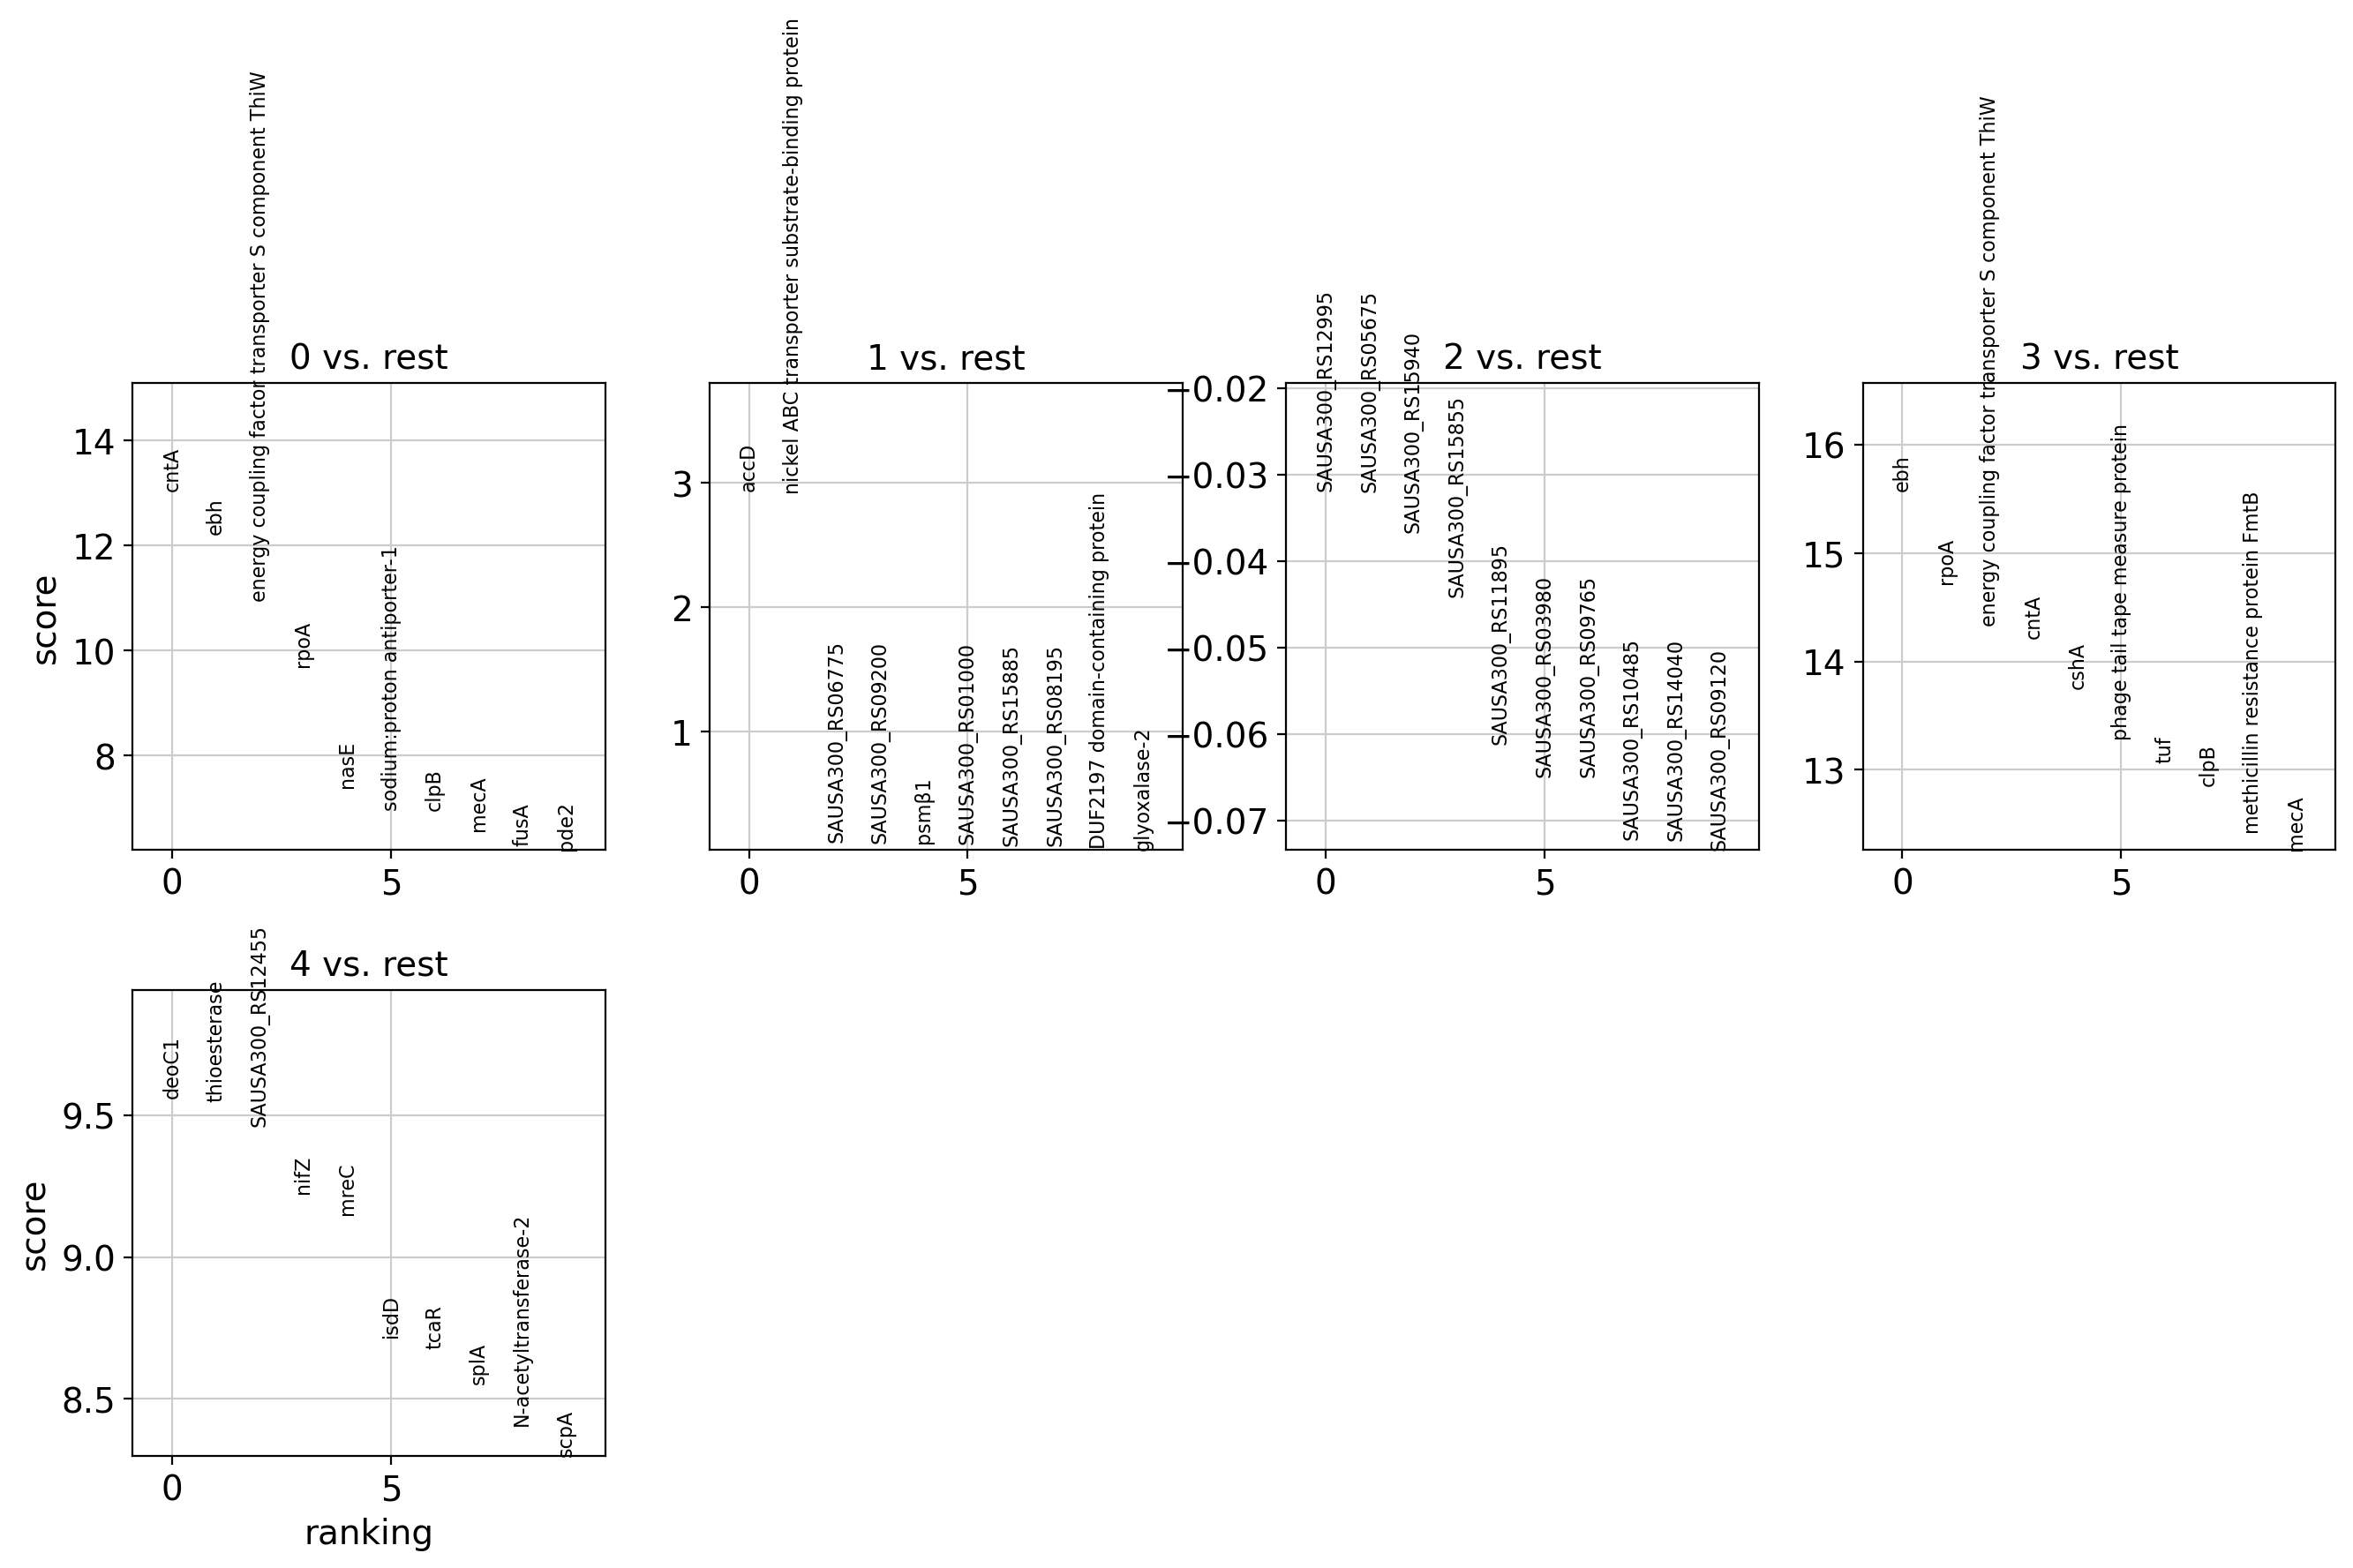

Top marker genes per cluster:
                                                   0  \
0                                               cntA   
1                                                ebh   
2  energy coupling factor transporter S component...   
3                                               rpoA   
4                                               nasE   

                                                  1                 2  \
0                                              accD  SAUSA300_RS12995   
1  nickel ABC transporter substrate-binding protein  SAUSA300_RS05675   
2                                  SAUSA300_RS06775  SAUSA300_RS15940   
3                                  SAUSA300_RS09200  SAUSA300_RS15855   
4                                             psmβ1  SAUSA300_RS11895   

                                                   3                 4  
0                                                ebh             deoC1  
1                                               

In [12]:
# --- NEW PART 1: IDENTIFYING MARKER GENES ---
# Compute marker genes for each cluster using the Wilcoxon rank-sum test
sc.tl.rank_genes_groups(adata_bacteria, 'leiden', method='wilcoxon')

# Visualize the top 10 marker genes per cluster
sc.pl.rank_genes_groups(adata_bacteria, n_genes=10, sharey=False)

# Display top 5 markers per cluster in a table
marker_table = pd.DataFrame(adata_bacteria.uns['rank_genes_groups']['names']).head(5)
print("Top marker genes per cluster:")
print(marker_table)

# Also print cluster composition to guide naming
print("\nCluster composition (% Biofilm vs Planktonic):")
print(dist_norm.round(2))

Clusters in data: ['0', '1', '2', '3', '4']
Clusters in name dict: ['0', '1', '2', '3', '4', '5', '6']

Unmapped cells: 0


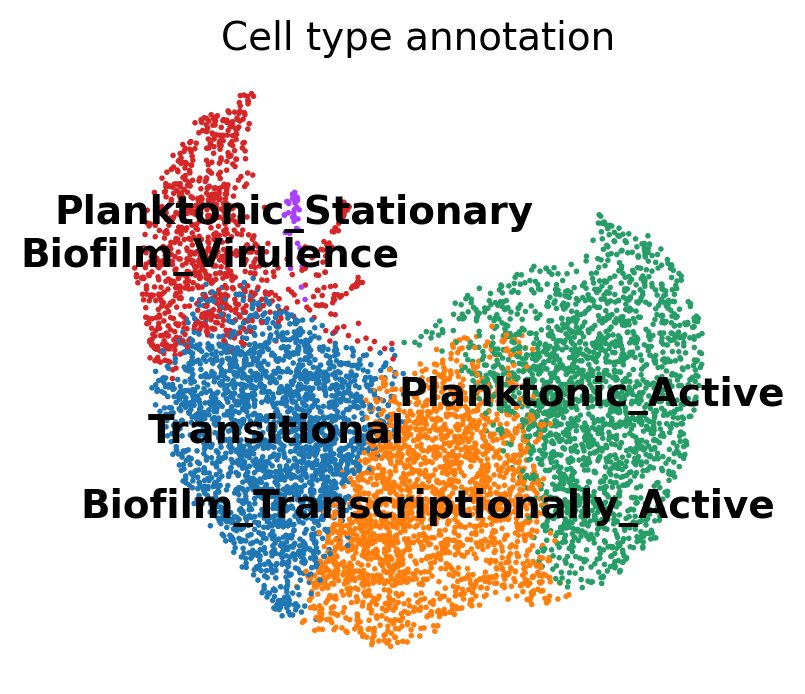

In [13]:
# --- NEW PART 2: ASSIGNING NAMES ---
# INSTRUCTIONS:
# 1. Look at the marker table printed above
# 2. Look at the stacked bar chart (which clusters are BF vs P dominated?)
# 3. Cross-reference with Table 1 from the Korshoj & Kielian (2024) paper:
#    - Cluster dominated by Planktonic + markers like rpoA, tuf, fusA = Planktonic_Active
#    - Cluster dominated by Biofilm + markers like citB, ltaS, isdH = Biofilm_Transcriptionally_Active
#    - Cluster dominated by Biofilm + markers like gpmA, polX, fdaB = Biofilm_Stress_Metabolism
#    - Cluster dominated by Biofilm + markers like clfB, fnbB, arcA = Biofilm_Virulence
#    - Cluster with qoxA, hemY, rplY = Planktonic_Stationary
#    - Cluster ~50/50 with sasA, pnpA = Transitional
#    - Cluster with nrdE = Biofilm_Replication

# ADJUST THESE NAMES based on what you see in YOUR marker table:
cluster_names = {
    '0': 'Transitional',               # ~50/50 BF/P in paper
    '1': 'Biofilm_Transcriptionally_Active',  # citB, ltaS, isdH
    '2': 'Planktonic_Active',           # rpoB, rpsC = most active planktonic
    '3': 'Biofilm_Virulence',           # clfB, fnbB, arcA
    '4': 'Planktonic_Stationary',       # qoxA, hemY
    '5': 'Biofilm_Stress_Metabolism',   # gpmA, polX, fdaB
    '6': 'Biofilm_Replication'          # nrdE
}

# Verify all 7 clusters are covered
print(f"Clusters in data: {sorted(adata_bacteria.obs['leiden'].unique())}")
print(f"Clusters in name dict: {sorted(cluster_names.keys())}")

# Add names to the data
adata_bacteria.obs['cell_type'] = adata_bacteria.obs['leiden'].map(cluster_names)

# Check for unmapped clusters (NaN means a cluster number is missing from the dict)
print(f"\nUnmapped cells: {adata_bacteria.obs['cell_type'].isna().sum()}")

# Verify in UMAP
sc.pl.umap(adata_bacteria, color='cell_type', legend_loc='on data', title='Cell type annotation')

## 8. CellTypist Training (De "Pipeline" stap)

In [14]:
# --- NEW PART 3: CELLTYPIST TRAINING ---
import celltypist

# Verify no NaN labels before training
print(f"Cells with missing labels: {adata_bacteria.obs['cell_type'].isna().sum()}")
assert adata_bacteria.obs['cell_type'].isna().sum() == 0, "Fix missing labels before training!"

# Train the model based on the names you assigned
# feature_selection=True automatically selects the most informative genes
model = celltypist.train(
    adata_bacteria,
    labels='cell_type',
    feature_selection=True,
    top_genes=300
)

# Save the model
model.write('Staph_Aureus_BF_P_Model.pkl')
print("Model successfully trained and saved!")

# Optional: inspect which genes drive each cell type
print("\nTop features per cell type:")
print(model.features)

🍳 Preparing data before training
👀 Detected scaled expression in the input data, will try the .raw attribute
🔬 Input data has 7437 cells and 2799 genes
⚖️ Scaling input data


Cells with missing labels: 0


🏋️ Training data using SGD logistic regression
🔎 Selecting features
🧬 1175 features are selected
🏋️ Starting the second round of training
🏋️ Training data using logistic regression
✅ Model training done!


Model successfully trained and saved!

Top features per cell type:
['dnaA' 'RNA-binding protein' 'gyrB' ... 'cspB' 'gidA' 'trmE']
